# BosonSR Annihilation: Basic Analysis

This notebook runs a compact smoke-analysis of the non-CBC `BosonSR_ann` waveform. 
The GW package wrapper loads the annihilation implementation from `../chris/julia_wf/annihilation.jl`, so the notebook resolves both paths from the parent repository layout.

In [1]:
using Pkg

candidate_dirs = unique([
    abspath(@__DIR__),
    abspath(pwd()),
    joinpath(abspath(@__DIR__), "GW_free_params.jl"),
    joinpath(abspath(pwd()), "GW_free_params.jl"),
])

project_dir_idx = findfirst(dir -> isfile(joinpath(dir, "Project.toml")) && isfile(joinpath(dir, "src", "GW.jl")), candidate_dirs)
project_dir_idx === nothing && error("Could not find GW_free_params.jl project directory from pwd=$(pwd()) and @__DIR__=$(@__DIR__)")
project_dir = candidate_dirs[project_dir_idx]
repo_dir = dirname(project_dir)

wrapper_source = joinpath(project_dir, "src", "waveforms", "bosonSR_annihilation.jl")
annihilation_source = joinpath(repo_dir, "chris", "julia_wf", "annihilation.jl")
@assert isfile(wrapper_source) wrapper_source
@assert isfile(annihilation_source) annihilation_source

Pkg.activate(project_dir)

include(joinpath(project_dir, "src", "GW.jl"))
using .GW
using .GW: BosonSR_ann, Pol, Strain, SNR, FisherMatrix, CE1Id_coordinates, CE1Id, ETLS, ETLMR, _available_waveforms
using Plots

default(size=(850, 420), linewidth=2, grid=true)

println("GW project: ", project_dir)
println("GW wrapper: ", wrapper_source)
println("annihilation implementation: ", annihilation_source)

  Activating 

GW project: /home/cherrytree/bosonSR_repo_/GW_free_params.jl

project at `~/bosonSR_repo_/GW_free_params.jl`



GW wrapper: /home/cherrytree/bosonSR_repo_/GW_free_params.jl/src/waveforms/bosonSR_annihilation.jl
annihilation implementation: /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation.jl


## Waveform and Parameters

`dL` is in Gpc in GWJulia. The value below is intentionally nearby (`1e-6` Gpc = 1 kpc) so the line is easy to inspect.

In [2]:
model = GW.BosonSR_ann()

M_solar = 10.0
mua = 2.0e-21
intrinsic = (M_solar, mua)

dL = 1.0e-6
theta = 1.0
phi = 2.0
iota = 0.4
psi = 0.7
tcoal = 0.2
phiCoal = 0.0
phase0 = 0.0

f_line = GW.waveform._ann_line_frequency(M_solar, mua)
fmin = max(2.0, 0.7 * f_line)
fmax = 1.3 * f_line
f = collect(range(fmin, fmax, length=800))

println("available non-CBC model: ", GW._available_waveforms("BosonSR_ann"))
println("parameter names: ", GW.waveform._parameter_names(model))
println("line frequency [Hz]: ", f_line)
println("analysis band [Hz]: ", (first(f), last(f)))
println("Chris function module: ", GW.waveform.ChrisAnnihilation)

available non-CBC model: BosonSR_ann()
parameter names: (:M_solar, :mua, :dL, :theta, :phi, :iota, :psi, :tcoal, :phiCoal)
line frequency [Hz]: 966.511101258368
analysis band [Hz]: (676.5577708808576, 1256.4644316358783)
Chris function module: Main.GW.waveform.ChrisAnnihilation


## Source-Frame Polarizations

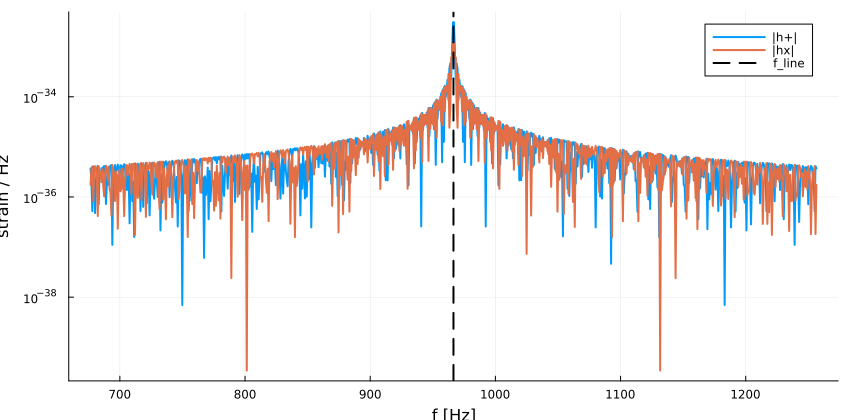

In [3]:
h_plus, h_cross = Pol(model, f, intrinsic, dL, iota, phase0)

plot(f, abs.(h_plus), label="|h+|", xlabel="f [Hz]", ylabel="strain / Hz", yscale=:log10)
plot!(f, abs.(h_cross), label="|hx|")
vline!([f_line], label="f_line", linestyle=:dash, color=:black)

## Detector Strain

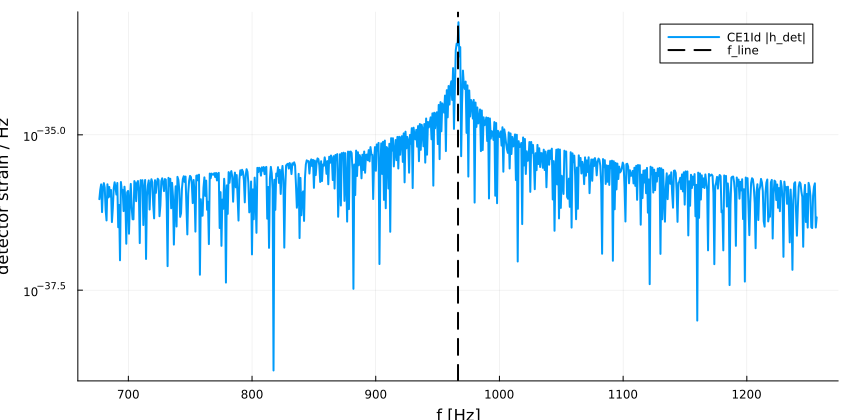

In [4]:
strain_ce = Strain(
    model,
    CE1Id_coordinates,
    f,
    intrinsic,
    dL,
    theta,
    phi,
    iota,
    psi,
    tcoal,
    phiCoal,
    phase0,
)

plot(f, abs.(strain_ce), label="CE1Id |h_det|", xlabel="f [Hz]", ylabel="detector strain / Hz", yscale=:log10)
vline!([f_line], label="f_line", linestyle=:dash, color=:black)

## SNR

In [5]:
network = [ETLS, ETLMR, CE1Id]

# Keep M_solar * mua in a range where the annihilation line remains positive.
M_solar_range = collect(range(1.0, 100.0, length=12))
mua_range = 2.0 .* 10.0 .^ range(-22, -21, length=12)
snr_matrix = fill(NaN, length(M_solar_range), length(mua_range));

In [6]:
for (i, M_solar_i) in enumerate(M_solar_range)
    for (j, mua_j) in enumerate(mua_range)
        intrinsic_ij = (M_solar_i, mua_j)
        f_line_ij = GW.waveform._ann_line_frequency(M_solar_i, mua_j)
        isfinite(f_line_ij) && f_line_ij > 0 || continue

        fmin_ij = max(2.0, 0.7 * f_line_ij)
        fmax_ij = 1.3 * f_line_ij
        fmax_ij > fmin_ij || continue

        try
            snr_matrix[i, j] = SNR(
                model,
                network,
                intrinsic_ij,
                dL,
                theta,
                phi,
                iota,
                psi,
                tcoal;
                fmin=fmin_ij,
                fmax=fmax_ij,
                res=80,
            )
        catch err
            @warn "SNR calculation failed" M_solar_i mua_j exception=(err, catch_backtrace())
        end
    end
end

snr_matrix

12×12 Matrix{Float64}:
 0.0          0.0          1.9187e-20   …  2.18703e-16  6.60638e-16
 2.98705e-14  9.58743e-14  3.09939e-13     2.56584e-9   5.36098e-9
 2.36025e-12  8.26504e-12  2.76143e-11     1.75543e-7   5.6895e-7
 3.00709e-11  1.15168e-10  3.88648e-10     3.57938e-6   8.03783e-6
 3.04211e-10  9.98165e-10  3.07863e-9      2.16364e-5   7.32265e-5
 1.06976e-9   3.54708e-9   1.53215e-8   …  9.29672e-5   0.000289638
 4.8158e-9    1.46279e-8   5.51354e-8      0.000367177  0.000905569
 1.29963e-8   4.42069e-8   1.50224e-7      0.00106575   0.00335179
 2.89303e-8   1.03124e-7   4.01696e-7      0.00269114   0.00714533
 8.45411e-8   2.64392e-7   9.14432e-7      0.00627702   0.0213792
 1.70792e-7   4.31001e-7   1.87422e-6   …  0.0138842    0.0346236
 3.27225e-7   8.54653e-7   2.60662e-6      0.0216717    0.0673155

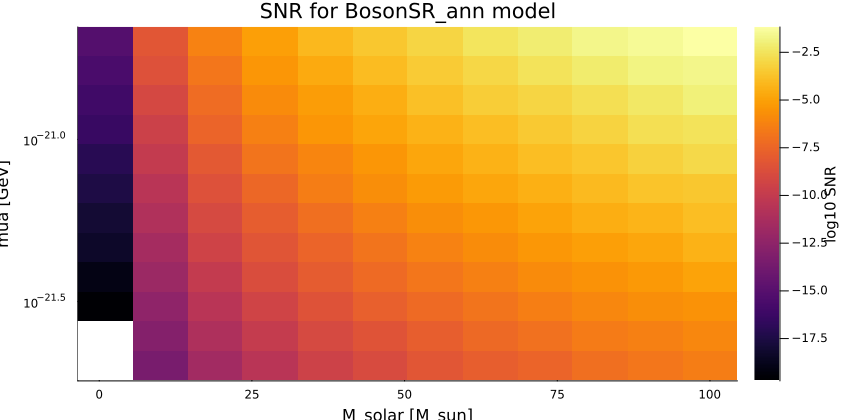

In [7]:
heatmap(
    M_solar_range,
    mua_range,
    log10.(snr_matrix)';
    ylabel="mua [GeV]",
    xlabel="M_solar [M_sun]",
    title="SNR for BosonSR_ann model",
    colorbar_title="log10 SNR",
    yscale=:log10,
)

## Small Fisher Matrix

This is intentionally low resolution. Increase `res` after the smoke run is stable.

9×9 Matrix{Float64}:
  7.3e43       1.33912e65   5.76696e17   …   2.44199e8    -2.60192e-6
  1.33912e65   8.17451e89   1.94729e41      -5.64175e32   -1.06772e19
  5.76696e17   1.94729e41   2.0632e-5        1.91649e-15  -3.14644e-28
 -5.24748e12   1.57874e37  -2.5379e-12       1.51398e-11  -2.49409e-15
 -3.35797e12   7.75797e36  -2.63537e-11      4.07994e-12  -6.72117e-16
  2.59465e11   3.18865e34   8.69491e-12  …   8.43583e-22  -3.56931e-35
  6.23291e12  -1.94751e37  -4.61044e-12      1.34803e-20   1.86483e-34
  2.44199e8   -5.64175e32   1.91649e-15      7.60183e-10  -1.2523e-13
 -2.60192e-6  -1.06772e19  -3.14644e-28     -1.2523e-13    2.0632e-17

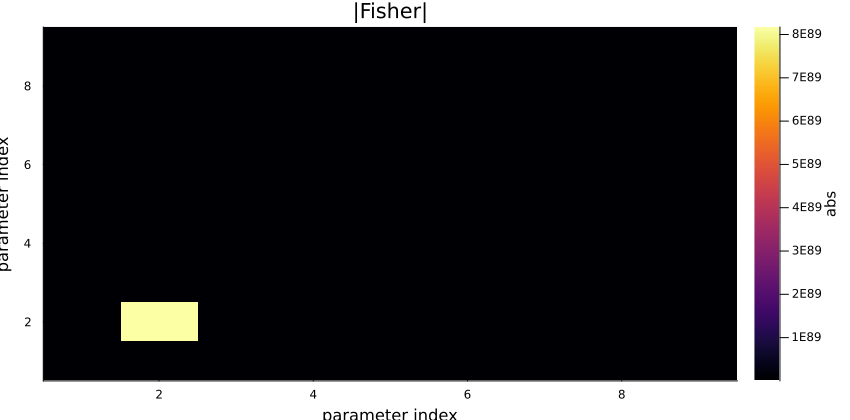

In [8]:
fisher_intrinsic = intrinsic
fisher_f_line = GW.waveform._ann_line_frequency(fisher_intrinsic...)
fisher_fmin = max(2.0, 0.7 * fisher_f_line)
fisher_fmax = 1.3 * fisher_f_line

fisher = FisherMatrix(
    model,
    CE1Id,
    fisher_intrinsic,
    dL,
    theta,
    phi,
    iota,
    psi,
    tcoal,
    phiCoal;
    res=800,
    fmin=fisher_fmin,
    fmax=fisher_fmax,
    rho_thres=nothing,
)

display(fisher)
heatmap(abs.(fisher), xlabel="parameter index", ylabel="parameter index", title="|Fisher|", colorbar_title="abs")